<a href="https://colab.research.google.com/github/abineshabi1027/FUTURE_DS_01/blob/main/Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_4432/3862187826.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=funnel_df, x='Stage', y='Count', palette='Blues_r', ax=ax1)
/tmp/ipykernel_4432/3862187826.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=channel_conversion.index, y=channel_conversion['Lead_to_Customer_Rate'] * 100, palette='viridis', ax=ax2)
/tmp/ipykernel_4432/3862187826.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)


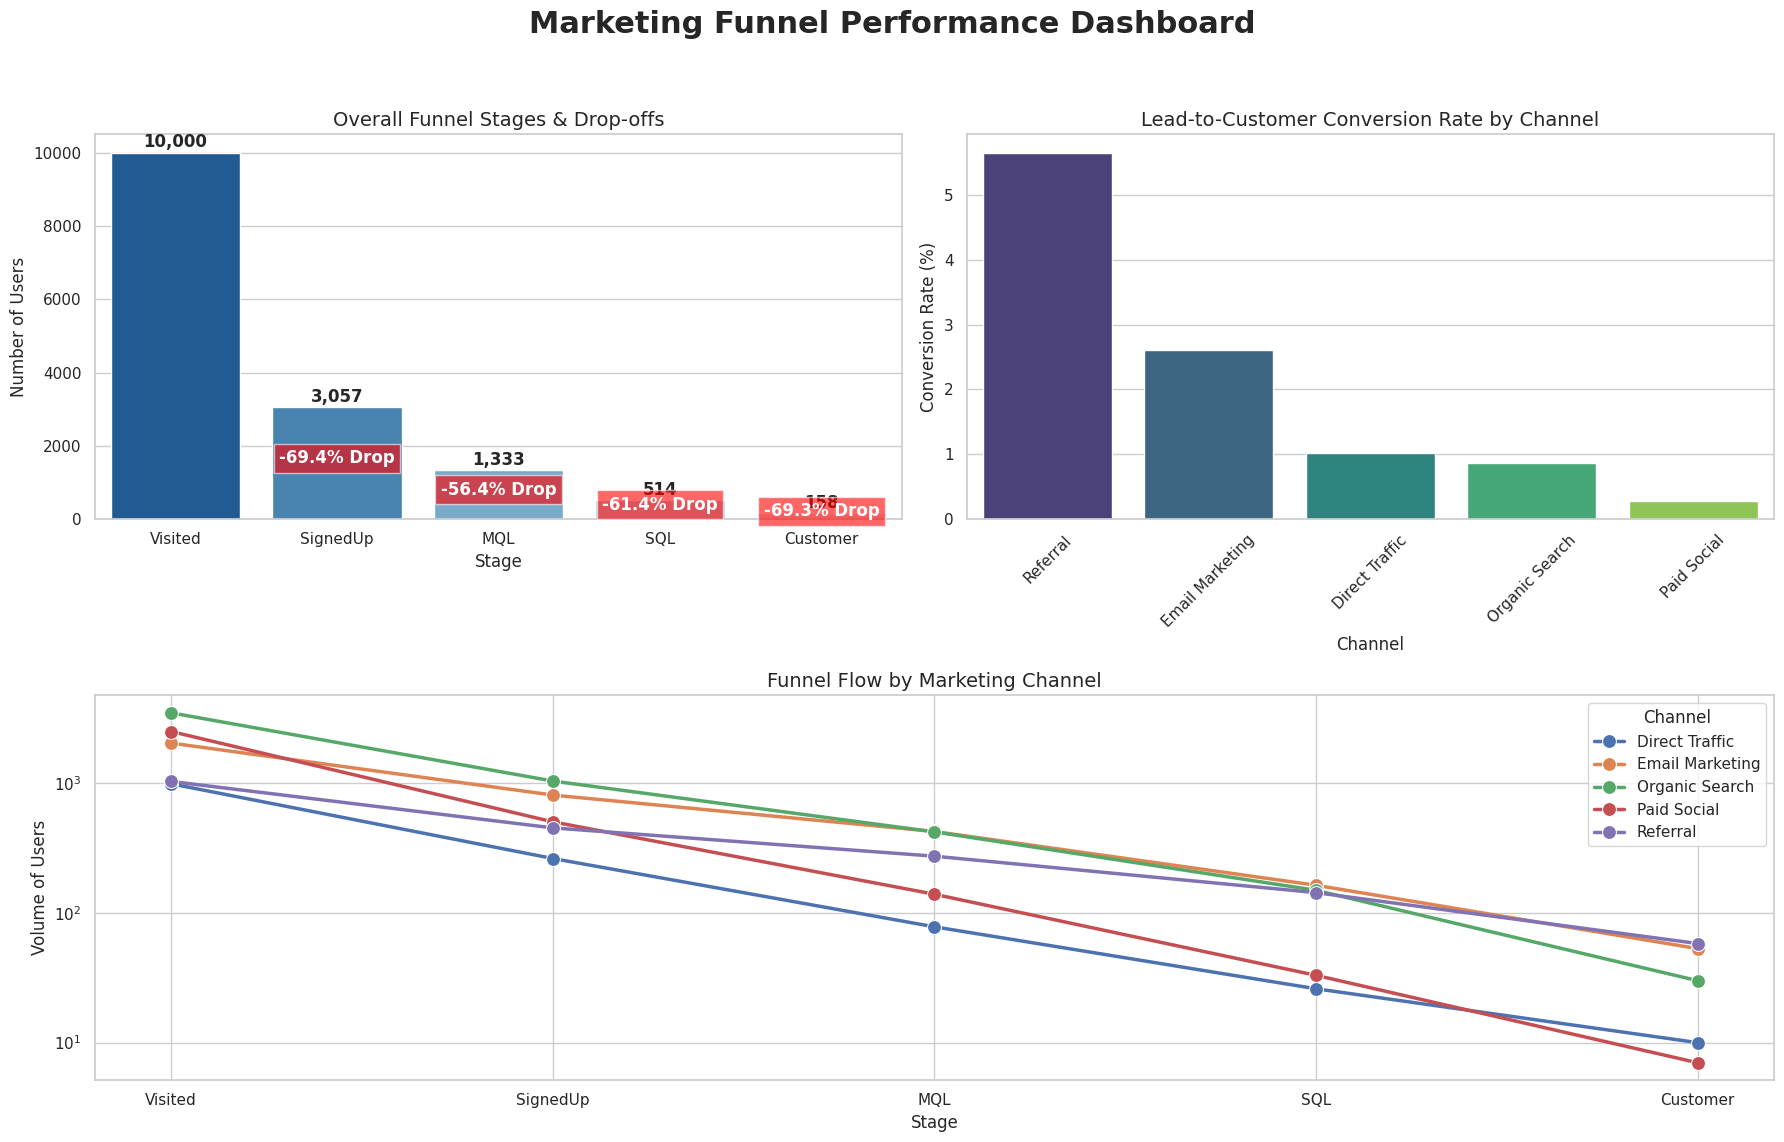

--- FUNNEL PERFORMANCE REPORT ---
   Stage  Count  Conversion_from_Previous  Overall_Conversion
 Visited  10000                  1.000000              1.0000
SignedUp   3057                  0.305700              0.3057
     MQL   1333                  0.436048              0.1333
     SQL    514                  0.385596              0.0514
Customer    158                  0.307393              0.0158

--- CHANNEL PERFORMANCE (LEAD TO CUSTOMER) ---
                Lead_to_Customer_Rate
Channel                              
Referral                        5.65%
Email Marketing                 2.61%
Direct Traffic                  1.02%
Organic Search                  0.86%
Paid Social                     0.28%

CRITICAL INSIGHT: The largest bottleneck in your funnel is from 'Visited' to 'SignedUp', with a drop-off rate of 69.4%.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(101)

n_leads = 10000
lead_ids = range(1, n_leads + 1)

channels = ['Organic Search', 'Paid Social', 'Email Marketing', 'Direct Traffic', 'Referral']
channel_probs = [0.35, 0.25, 0.20, 0.10, 0.10]
lead_channels = np.random.choice(channels, n_leads, p=channel_probs)

data = []
for i in range(n_leads):
    channel = lead_channels[i]

    if channel == 'Referral':
        probs = [1.0, 0.45, 0.60, 0.50, 0.40]
    elif channel == 'Organic Search':
        probs = [1.0, 0.30, 0.40, 0.35, 0.25]
    elif channel == 'Email Marketing':
        probs = [1.0, 0.40, 0.50, 0.40, 0.30]
    elif channel == 'Paid Social':
        probs = [1.0, 0.20, 0.30, 0.25, 0.20]
    else:
        probs = [1.0, 0.25, 0.35, 0.30, 0.25]

    visited = 1
    signed_up = np.random.binomial(1, probs[1]) if visited else 0
    mql = np.random.binomial(1, probs[2]) if signed_up else 0
    sql = np.random.binomial(1, probs[3]) if mql else 0
    customer = np.random.binomial(1, probs[4]) if sql else 0

    data.append([visited, signed_up, mql, sql, customer, channel])

df = pd.DataFrame(data, columns=['Visited', 'SignedUp', 'MQL', 'SQL', 'Customer', 'Channel'])

stages = ['Visited', 'SignedUp', 'MQL', 'SQL', 'Customer']

funnel_counts = df[stages].sum()
funnel_df = pd.DataFrame({'Stage': stages, 'Count': funnel_counts.values})

funnel_df['Conversion_from_Previous'] = funnel_df['Count'].pct_change() + 1
funnel_df.loc[0, 'Conversion_from_Previous'] = 1.0
funnel_df['Overall_Conversion'] = funnel_df['Count'] / funnel_df['Count'].iloc[0]
funnel_df['Drop_off_Rate'] = 1 - funnel_df['Conversion_from_Previous']

channel_funnel = df.groupby('Channel')[stages].sum()
channel_conversion = pd.DataFrame({
    'Lead_to_Customer_Rate': channel_funnel['Customer'] / channel_funnel['Visited']
}).sort_values(by='Lead_to_Customer_Rate', ascending=False)

sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Marketing Funnel Performance Dashboard', fontsize=22, fontweight='bold')

ax1 = plt.subplot(2, 2, 1)
sns.barplot(data=funnel_df, x='Stage', y='Count', palette='Blues_r', ax=ax1)
for i, count in enumerate(funnel_df['Count']):
    ax1.text(i, count + 150, f"{count:,.0f}", ha='center', fontsize=12, fontweight='bold')
    if i > 0:
        drop = funnel_df['Drop_off_Rate'].iloc[i] * 100
        ax1.text(i, count / 2, f"-{drop:.1f}% Drop", ha='center', color='white', fontweight='bold', bbox=dict(facecolor='red', alpha=0.6))
ax1.set_title('Overall Funnel Stages & Drop-offs', fontsize=14)
ax1.set_ylabel('Number of Users')

ax2 = plt.subplot(2, 2, 2)
sns.barplot(x=channel_conversion.index, y=channel_conversion['Lead_to_Customer_Rate'] * 100, palette='viridis', ax=ax2)
ax2.set_title('Lead-to-Customer Conversion Rate by Channel', fontsize=14)
ax2.set_ylabel('Conversion Rate (%)')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)

ax3 = plt.subplot(2, 2, (3, 4))
channel_melted = channel_funnel.reset_index().melt(id_vars='Channel', value_vars=stages, var_name='Stage', value_name='Count')
sns.lineplot(data=channel_melted, x='Stage', y='Count', hue='Channel', marker='o', linewidth=2.5, markersize=10, ax=ax3)
ax3.set_title('Funnel Flow by Marketing Channel', fontsize=14)
ax3.set_ylabel('Volume of Users')
ax3.set_yscale('log')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("--- FUNNEL PERFORMANCE REPORT ---")
print(funnel_df[['Stage', 'Count', 'Conversion_from_Previous', 'Overall_Conversion']].to_string(index=False))

print("\n--- CHANNEL PERFORMANCE (LEAD TO CUSTOMER) ---")
print((channel_conversion * 100).round(2).astype(str) + '%')

worst_stage_idx = funnel_df['Drop_off_Rate'].idxmax()
worst_stage = funnel_df.iloc[worst_stage_idx]['Stage']
previous_stage = funnel_df.iloc[worst_stage_idx - 1]['Stage']
drop_rate = funnel_df.iloc[worst_stage_idx]['Drop_off_Rate'] * 100

print(f"\nCRITICAL INSIGHT: The largest bottleneck in your funnel is from '{previous_stage}' to '{worst_stage}', with a drop-off rate of {drop_rate:.1f}%.")